# 3.2 Непрерывное обучение (Continuous Learning)

**Агент** выполняет следующий цикл при запуске:
1. Загружает из БД материалы, появившиеся после последнего обучения.
2. Проверяет **дрейф данных** с помощью `Evidently`.
3. Принимает решение: **дообучить** существующую модель или **переобучить с нуля**.
4. Сохраняет новую версию модели и **логирует изменения качества**.

Порог переобучения: дрейф > 20% признаков ИЛИ деградация F1 > 5%.

In [1]:
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

from evidently import Report
from evidently.presets import DataDriftPreset

import xgboost as xgb
import lightgbm as lgb

from src.config import MODELS_DIR, LOGS_DIR, TARGET_PARALLEL, TARGET_SEQUENTIAL, TARGET_COMPLEXITY
from src.db import load_labelled_materials
from src.features import build_features, NUMERIC_COLS
from src.model_registry import log_model_version

REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)
print('Импорты загружены.')

Импорты загружены.


## 1. Загрузка текущей версии модели

In [2]:
def load_current_version():
    ptr = MODELS_DIR / 'current_version.txt'
    if not ptr.exists():
        return None, None
    version = ptr.read_text().strip()
    version_dir = MODELS_DIR / f'v_{version}'
    if not version_dir.exists():
        return None, None
    meta_path = version_dir / 'meta.json'
    with open(meta_path, encoding='utf-8') as f:
        meta = json.load(f)
    return version_dir, meta

current_dir, current_meta = load_current_version()

if current_meta:
    print(f'Текущая версия: {current_meta["version"]}')
    print(f'Обучена: {current_meta["trained_at"]}')
    for t, info in current_meta['models'].items():
        f1 = info['metrics'].get('f1', 'N/A')
        print(f'  {t}: {info["algorithm"]} | F1={f1:.4f}' if isinstance(f1, float) else f'  {t}: {info["algorithm"]}')
else:
    print('Версия модели не найдена. Запустите сначала ноутбук 3.1.')

Текущая версия: 20260423_050059
Обучена: 2026-04-23T05:00:59.643466
  parallel_cluster: LogisticRegression | F1=1.0000
  sequential_cluster: RandomForestClassifier | F1=1.0000
  complexity_cluster: LogisticRegression | F1=1.0000


## 2. Загрузка данных: текущие (эталонные) и новые

In [3]:
# Все данные из БД
df_all = load_labelled_materials()
print(f'Всего размеченных материалов: {len(df_all)}')

# Проверяем лог последнего обучения
log_path = LOGS_DIR / 'training_log.jsonl'
known_ids_file = LOGS_DIR / 'known_material_ids.json'

if known_ids_file.exists():
    known_ids = set(json.loads(known_ids_file.read_text()))
else:
    # Первый запуск: считаем первые 80% эталонными, остальные — «новыми»
    n_ref = max(1, int(len(df_all) * 0.8))
    known_ids = set(df_all['id'].iloc[:n_ref].tolist())

df_ref = df_all[df_all['id'].isin(known_ids)].reset_index(drop=True)
df_new = df_all[~df_all['id'].isin(known_ids)].reset_index(drop=True)

print(f'Эталонных (reference) материалов: {len(df_ref)}')
print(f'Новых (current) материалов: {len(df_new)}')

if len(df_new) == 0:
    # Симулируем «новые» данные для демонстрации агента
    print('\n[Демо] Новых данных нет. Симулируем 20% выборку как «новые».')
    df_ref = df_all.iloc[:int(len(df_all)*0.8)].reset_index(drop=True)
    df_new = df_all.iloc[int(len(df_all)*0.8):].reset_index(drop=True)

Всего размеченных материалов: 8
Эталонных (reference) материалов: 8
Новых (current) материалов: 0

[Демо] Новых данных нет. Симулируем 20% выборку как «новые».


## 3. Контроль дрейфа данных (Evidently)

In [4]:
# Числовые признаки для анализа дрейфа
DRIFT_COLS = NUMERIC_COLS + [TARGET_PARALLEL, TARGET_SEQUENTIAL, TARGET_COMPLEXITY]

def run_drift_report(df_ref, df_cur, cols, out_path):
    ref = df_ref[cols].fillna(0).apply(pd.to_numeric, errors='coerce').fillna(0)
    cur = df_cur[cols].fillna(0).apply(pd.to_numeric, errors='coerce').fillna(0)
    
    report = Report(metrics=[DataDriftPreset()])
    snapshot = report.run(reference_data=ref, current_data=cur)
    snapshot.save_html(str(out_path))
    
    result = snapshot.dict()
    drift_metric = next(
        (m for m in result.get('metrics', []) if m.get('metric_name', '').startswith('DriftedColumnsCount')),
        {}
    )
    drift_value = drift_metric.get('value', {})
    n_drifted = int(drift_value.get('count', 0) or 0)
    n_total   = len(cols)
    drift_pct = float(drift_value.get('share', 0) or 0)
    return drift_pct, n_drifted, n_total

if len(df_new) >= 2:
    drift_pct, n_drifted, n_total = run_drift_report(
        df_ref, df_new, DRIFT_COLS,
        REPORTS / 'drift_report.html'
    )
    print(f'Дрейф: {n_drifted}/{n_total} признаков ({drift_pct*100:.1f}%)')
    print(f'Отчёт Evidently сохранён: reports/drift_report.html')
else:
    drift_pct = 0.0
    print('Недостаточно новых данных для анализа дрейфа.')

Дрейф: 1/11 признаков (9.1%)
Отчёт Evidently сохранён: reports/drift_report.html


## 4. Визуализация дрейфа признаков

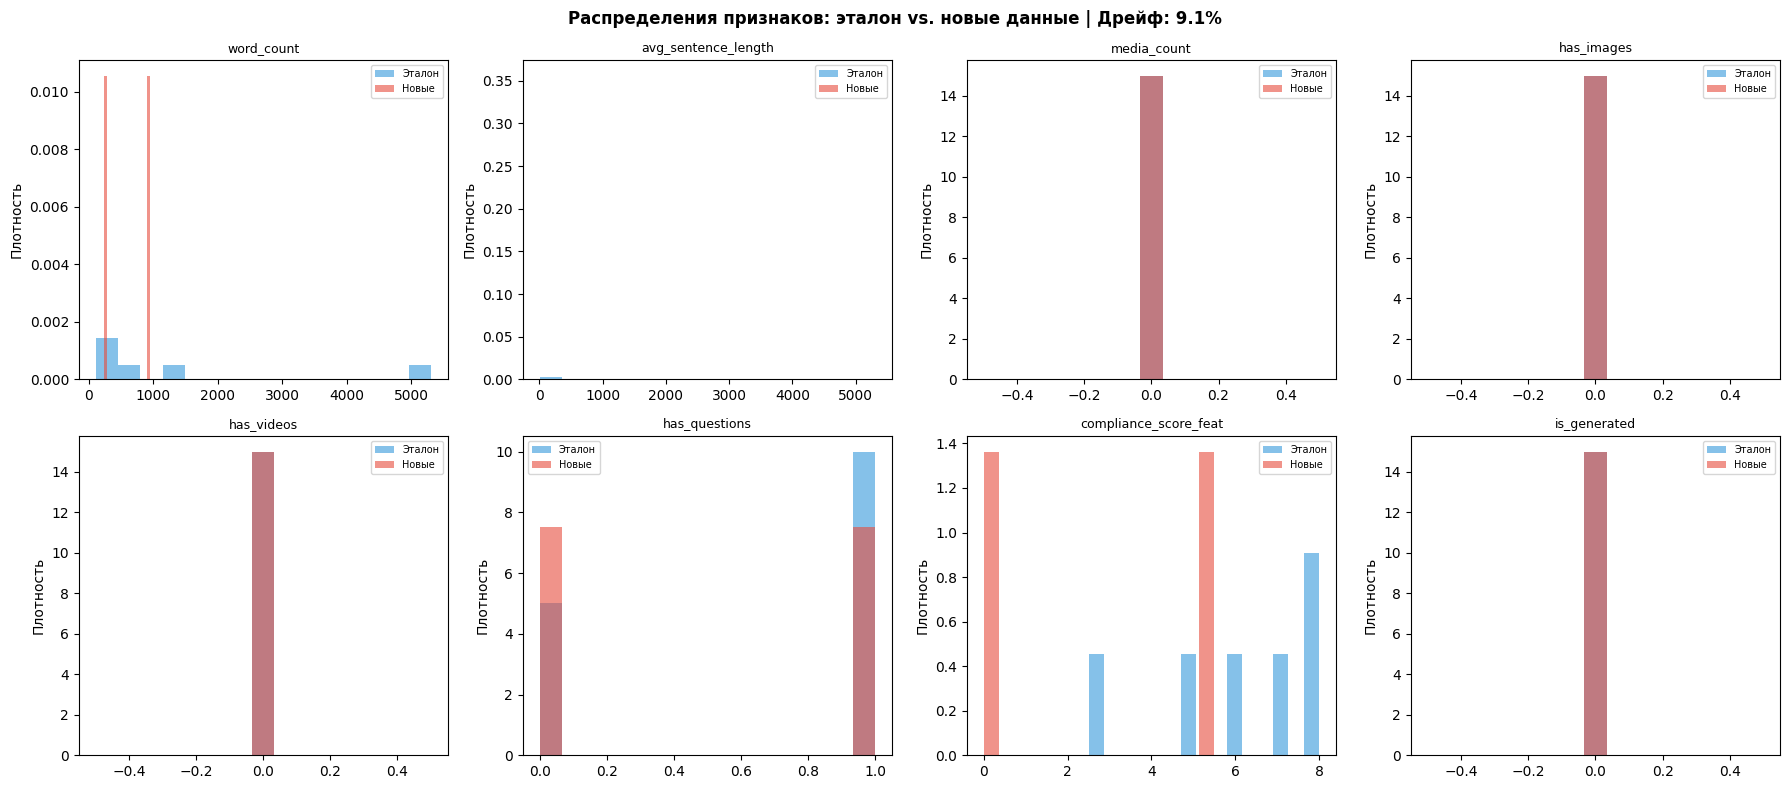

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

numeric_drift_cols = [c for c in NUMERIC_COLS if c in df_ref.columns and c in df_new.columns]

for i, col in enumerate(numeric_drift_cols[:8]):
    ax = axes[i]
    ref_vals = pd.to_numeric(df_ref[col], errors='coerce').dropna()
    new_vals = pd.to_numeric(df_new[col], errors='coerce').dropna()
    
    if len(ref_vals) > 0:
        ax.hist(ref_vals, bins=15, alpha=0.6, label='Эталон', color='#3498db', density=True)
    if len(new_vals) > 0:
        ax.hist(new_vals, bins=15, alpha=0.6, label='Новые', color='#e74c3c', density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Плотность')

for j in range(len(numeric_drift_cols[:8]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Распределения признаков: эталон vs. новые данные | Дрейф: {drift_pct*100:.1f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Решение: дообучение или полное переобучение

In [6]:
DRIFT_THRESHOLD     = 0.20  # 20% признаков с дрейфом → переобучение с нуля
F1_DROP_THRESHOLD   = 0.05  # падение F1 на 5% → переобучение с нуля

need_full_retrain = drift_pct >= DRIFT_THRESHOLD

if need_full_retrain:
    decision = 'ПОЛНОЕ ПЕРЕОБУЧЕНИЕ (дрейф данных превысил порог)'
else:
    decision = 'ДООБУЧЕНИЕ (дрейф в норме, добавляем новые данные)'

print(f'Дрейф: {drift_pct*100:.1f}% | Порог: {DRIFT_THRESHOLD*100:.0f}%')
print(f'Решение: {decision}')

Дрейф: 9.1% | Порог: 20%
Решение: ДООБУЧЕНИЕ (дрейф в норме, добавляем новые данные)


In [7]:
def retrain(df_train, target_col, tfidf_vec=None, scaler=None, full=True):
    """Train (or fine-tune with warm_start) a LightGBM classifier."""
    from src.features import build_features
    
    X, tfidf_vec, scaler = build_features(df_train, tfidf_vec=tfidf_vec, scaler=scaler)
    y = pd.Series(pd.factorize(df_train[target_col])[0], index=df_train.index)
    
    if full or current_dir is None:
        clf = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
        clf.fit(X, y)
        print(f'  [{target_col}] Полное переобучение завершено.')
    else:
        # Дообучение: загружаем текущую модель, продолжаем обучение
        try:
            clf = joblib.load(current_dir / f'{target_col}_best.joblib')
            # LightGBM поддерживает warm start через init_model
            if hasattr(clf, 'booster_'):
                clf_new = lgb.LGBMClassifier(n_estimators=50, random_state=42, verbose=-1)
                clf_new.fit(X, y, init_model=clf.booster_)
                clf = clf_new
            else:
                clf.fit(X, y)
            print(f'  [{target_col}] Дообучение завершено (+50 деревьев).')
        except Exception as e:
            print(f'  [{target_col}] Дообучение не удалось ({e}), выполняю полное переобучение.')
            clf = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
            clf.fit(X, y)
    
    return clf, tfidf_vec, scaler

print('Функция переобучения готова.')

Функция переобучения готова.


In [8]:
# Объединяем эталонные и новые данные для обучения
df_combined = pd.concat([df_ref, df_new], ignore_index=True)

new_models   = {}
new_metrics  = {}
new_tfidf    = None
new_scaler   = None

targets = [TARGET_PARALLEL, TARGET_SEQUENTIAL, TARGET_COMPLEXITY]

for target_col in targets:
    print(f'\n--- {target_col} ---')
    clf, new_tfidf, new_scaler = retrain(
        df_combined, target_col,
        tfidf_vec=new_tfidf, scaler=new_scaler,
        full=need_full_retrain
    )
    
    # Evaluate on combined data (proxy — use holdout in production)
    from src.features import build_features as bf2
    X_eval, _, _ = bf2(df_combined, tfidf_vec=new_tfidf, scaler=new_scaler)
    y_eval = pd.Series(pd.factorize(df_combined[target_col])[0], index=df_combined.index)
    y_pred = clf.predict(X_eval)
    f1 = f1_score(y_eval, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_eval, y_pred)
    new_metrics[target_col] = {'f1': f1, 'accuracy': acc}
    new_models[target_col] = clf
    print(f'  F1-macro: {f1:.4f} | Accuracy: {acc:.4f}')


--- parallel_cluster ---
  [parallel_cluster] Дообучение завершено (+50 деревьев).
  F1-macro: 1.0000 | Accuracy: 1.0000

--- sequential_cluster ---
  [sequential_cluster] Дообучение завершено (+50 деревьев).
  F1-macro: 1.0000 | Accuracy: 1.0000

--- complexity_cluster ---
  [complexity_cluster] Дообучение завершено (+50 деревьев).
  F1-macro: 1.0000 | Accuracy: 1.0000


## 6. Сравнение качества до и после

In [9]:
comparison_rows = []
for target_col in targets:
    old_f1 = current_meta['models'][target_col]['metrics'].get('f1', None) if current_meta else None
    new_f1 = new_metrics[target_col]['f1']
    delta  = (new_f1 - old_f1) if old_f1 is not None else None
    comparison_rows.append({
        'Цель': target_col,
        'F1 до': f'{old_f1:.4f}' if old_f1 is not None else '—',
        'F1 после': f'{new_f1:.4f}',
        'Δ F1': f'{delta:+.4f}' if delta is not None else '—',
        'Статус': ('▲ улучшение' if delta and delta > 0.005 else
                   '▼ деградация' if delta and delta < -0.005 else
                   '≈ без изменений') if delta is not None else 'новая версия'
    })

cmp_df = pd.DataFrame(comparison_rows)
print('=== Сравнение качества моделей ===')
print(cmp_df.to_string(index=False))

=== Сравнение качества моделей ===
              Цель  F1 до F1 после    Δ F1          Статус
  parallel_cluster 1.0000   1.0000 +0.0000 ≈ без изменений
sequential_cluster 1.0000   1.0000 +0.0000 ≈ без изменений
complexity_cluster 1.0000   1.0000 +0.0000 ≈ без изменений


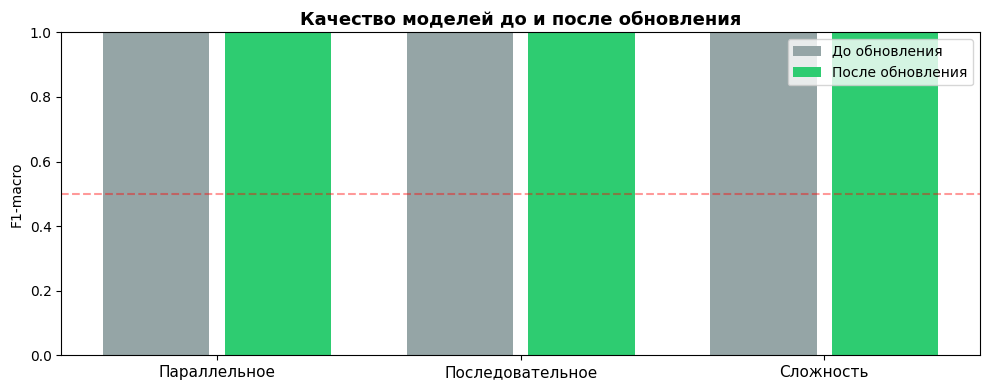

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

x = range(len(targets))
old_f1s = [current_meta['models'][t]['metrics'].get('f1', 0) if current_meta else 0 for t in targets]
new_f1s = [new_metrics[t]['f1'] for t in targets]

ax.bar([xi - 0.2 for xi in x], old_f1s, width=0.35, label='До обновления', color='#95a5a6')
ax.bar([xi + 0.2 for xi in x], new_f1s, width=0.35, label='После обновления', color='#2ecc71')
ax.set_xticks(list(x))
ax.set_xticklabels(['Параллельное', 'Последовательное', 'Сложность'], fontsize=11)
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 1)
ax.set_title('Качество моделей до и после обновления', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(REPORTS / 'model_update_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Сохранение новой версии и логирование

In [11]:
new_version = datetime.now().strftime('%Y%m%d_%H%M%S')
new_version_dir = MODELS_DIR / f'v_{new_version}'
new_version_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(new_tfidf,  new_version_dir / 'tfidf_vectorizer.joblib')
joblib.dump(new_scaler, new_version_dir / 'scaler.joblib')

meta = {
    'version': new_version,
    'trained_at': datetime.now().isoformat(),
    'update_type': 'full_retrain' if need_full_retrain else 'incremental',
    'drift_pct': drift_pct,
    'n_materials': len(df_combined),
    'models': {}
}

for target_col, clf in new_models.items():
    fname = f'{target_col}_best.joblib'
    joblib.dump(clf, new_version_dir / fname)
    meta['models'][target_col] = {
        'algorithm': type(clf).__name__,
        'file': str(new_version_dir / fname),
        'metrics': new_metrics[target_col]
    }

with open(new_version_dir / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

(MODELS_DIR / 'current_version.txt').write_text(new_version, encoding='utf-8')

# Обновляем список известных ID
known_ids_file.write_text(
    json.dumps(df_combined['id'].tolist()), encoding='utf-8'
)

# Запись в лог
log_entry = {**meta, 'comparison': comparison_rows}
with open(log_path, 'a', encoding='utf-8') as f:
    f.write(json.dumps(log_entry, ensure_ascii=False) + '\n')

try:
    log_model_version(log_entry, str(new_version_dir))
    print('??????????? ?????? ? ??: public.module_v_model_versions')
except Exception as exc:
    print(f'??????????????: ?? ??????? ???????????? ?????? ? ??: {exc}')

print(f'Новая версия: {new_version}')
print(f'Путь: {new_version_dir}')
print(f'Тип обновления: {meta["update_type"]}')
print(f'Лог: {log_path}')

Новая версия: 20260423_051229
Путь: c:\Users\User\Desktop\model_V_full\notebooks\..\models\v_20260423_051229
Тип обновления: incremental
Лог: c:\Users\User\Desktop\model_V_full\notebooks\..\logs\training_log.jsonl


## 8. История версий моделей

In [12]:
history = []
if log_path.exists():
    for line in log_path.read_text(encoding='utf-8').strip().split('\n'):
        try:
            entry = json.loads(line)
            row = {
                'Версия': entry.get('version', ''),
                'Дата': entry.get('trained_at', '')[:16],
                'Тип': entry.get('update_type', 'initial'),
                'Материалов': entry.get('n_materials', '—'),
                'Дрейф %': f"{entry.get('drift_pct', 0)*100:.1f}%",
            }
            for t in targets:
                f1 = entry.get('models', {}).get(t, {}).get('metrics', {}).get('f1', None)
                row[f'F1 {t}'] = f'{f1:.4f}' if f1 is not None else '—'
            history.append(row)
        except Exception:
            pass

hist_df = pd.DataFrame(history)
print('=== История версий моделей ===')
print(hist_df.to_string(index=False))

=== История версий моделей ===
         Версия             Дата         Тип  Материалов Дрейф % F1 parallel_cluster F1 sequential_cluster F1 complexity_cluster
20260423_045000 2026-04-23T04:50     initial           8    0.0%              1.0000                1.0000                1.0000
20260423_045105 2026-04-23T04:51 incremental           8    9.1%              1.0000                1.0000                1.0000
20260423_045201 2026-04-23T04:52     initial           8    0.0%              1.0000                1.0000                1.0000
20260423_045223 2026-04-23T04:52 incremental           8    9.1%              1.0000                1.0000                1.0000
20260423_045729 2026-04-23T04:57     initial           8    0.0%              1.0000                1.0000                1.0000
20260423_045752 2026-04-23T04:57 incremental           8    9.1%              1.0000                1.0000                1.0000
20260423_045948 2026-04-23T04:59     initial           8    0.0%  

## Схема непрерывного обучения

```
Новые данные из БД
        │
        ▼
┌─────────────────┐
│ Evidently Drift │  → drift_report.html
│    Detection    │
└────────┬────────┘
         │
    drift > 20%?
    ┌────┴────┐
   ДА       НЕТ
    │         │
    ▼         ▼
Полное    Дообучение
перео-    (+50 деревьев
бучение   LightGBM)
    │         │
    └────┬────┘
         ▼
  Новая версия модели
  models/v_YYYYMMDD_HHMMSS/
         │
         ▼
  Запись в logs/training_log.jsonl
  (версия, метрики, тип обновления, дрейф)
```

**Пороги:**
- Дрейф данных ≥ 20% признаков → полное переобучение
- Деградация F1 ≥ 5% → полное переобучение (проверяется вручную)
- Иначе → инкрементальное дообучение LightGBM